`` Full name: Phạm Ngọc Hào `` <br>
`` Student ID: 23110146``

# I. Practice 1: In-Class Lab Implementation

## 1. Environment setup

In [1]:
!pip install datasets==2.18.0
!pip install underthesea

In [2]:
!pwd
!ls

/content
aclImdb  aclImdb_v1.tar.gz  sample_data


In [3]:
import sys
import numpy as np
import pandas as pd
import re
import sklearn
import math
import scipy.sparse as sp
import nltk

from sklearn import datasets
from sklearn.datasets import load_files
from datasets import load_dataset
from underthesea import word_tokenize
from nltk import ngrams
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import MultinomialNB
from collections import Counter
from scipy.sparse import csr_matrix
from sklearn.model_selection import GridSearchCV


## 2. Data Preprocessing

In [4]:
dataset = load_dataset("uitnlp/vietnamese_students_feedback")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
train_set = dataset["train"]
train_set

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 11426
})

In [6]:
test_set = dataset["test"]
test_set

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 3166
})

In [7]:
df = pd.DataFrame(train_set)

print(df.head(15))
print("="*50)
print(df["topic"].value_counts())
print(df["sentiment"].value_counts())

                                             sentence  sentiment  topic
0                           slide giáo trình đầy đủ .          2      1
1      nhiệt tình giảng dạy , gần gũi với sinh viên .          2      0
2                đi học đầy đủ full điểm chuyên cần .          0      1
3   chưa áp dụng công nghệ thông tin và các thiết ...          0      0
4   thầy giảng bài hay , có nhiều bài tập ví dụ ng...          2      0
5   giảng viên đảm bảo thời gian lên lớp , tích cự...          2      0
6   em sẽ nợ môn này , nhưng em sẽ học lại ở các h...          1      3
7   thời lượng học quá dài , không đảm bảo tiếp th...          0      1
8   nội dung môn học có phần thiếu trọng tâm , hầu...          0      1
9   cần nói rõ hơn bằng cách trình bày lên bảng th...          0      1
10         thầy rất tận tình và đi dạy rất đúng giờ .          2      0
11                                     dễ bị áp lực .          0      3
12  đang dạy thầy wzjwz208 đi qua nước ngoài giữa ...          1

The **UIT-VSFC** contains student feedback categorized into sentiment and topic. Each record comprises the following primary information:
- **Sentence**: students' feedbacks (raw text).
- **Sentiment**: emotional labels (integer numbers, 0, 1, 2 corresponding to `negative`, `positive`, and `neutral`).
- **Topic**: topic labels (integer numbers, 0, 1, 2, 3 corresponding to `Lecturers`, `Curriculum`, `Facility`, and `Other`).

In [8]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r"[^\w\s]", "", text)
  text = re.sub(r"\d+", "", text)
  return text
df["clean_text"] = df["sentence"].apply(clean_text)


In [9]:
def tokenize_vi(text):
  return word_tokenize(text, format = "text")

df["tokenized"] = df["clean_text"].apply(tokenize_vi)

In [10]:
df

,sentence,sentiment,topic,clean_text,tokenized
0,slide giáo trình đầy đủ .,2,1,slide giáo trình đầy đủ,slide giáo_trình đầy_đủ
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,nhiệt tình giảng dạy gần gũi với sinh viên,nhiệt_tình giảng_dạy gần_gũi với sinh_viên
2,đi học đầy đủ full điểm chuyên cần .,0,1,đi học đầy đủ full điểm chuyên cần,đi học đầy_đủ full_điểm chuyên cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp_dụng công_nghệ_thông_tin và các thiết_...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,thầy giảng bài hay có nhiều bài tập ví dụ nga...,thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...
...,...,...,...,...,...
11421,chỉ vì môn game mà em học hai lần mà không qua...,0,1,chỉ vì môn game mà em học hai lần mà không qua...,chỉ vì môn game mà em học hai lần mà không qua...
11422,em cảm ơn cô nhiều .,2,0,em cảm ơn cô nhiều,em cảm_ơn cô nhiều
11423,giao bài tập quá nhiều .,0,0,giao bài tập quá nhiều,giao bài_tập quá nhiều
11424,"giáo viên dạy dễ hiểu , nhiệt tình .",2,0,giáo viên dạy dễ hiểu nhiệt tình,giáo_viên dạy dễ hiểu nhiệt_tình


In [11]:
example_word_list = df["sentence"][0]
example_word_list_clean = df["clean_text"][0]
example_word_list_tokenized = df["tokenized"][0]

print(example_word_list)
print(example_word_list_clean)
print(example_word_list_tokenized)

slide giáo trình đầy đủ .
slide giáo trình đầy đủ 
slide giáo_trình đầy_đủ


In [12]:
# split sentence word-by-word
example_or = example_word_list.split()
example_clean = example_word_list_clean.split()
example_tokenized = example_word_list_tokenized.split()

print(example_or)
print(example_clean)
print(example_tokenized)

['slide', 'giáo', 'trình', 'đầy', 'đủ', '.']
['slide', 'giáo', 'trình', 'đầy', 'đủ']
['slide', 'giáo_trình', 'đầy_đủ']


In [13]:
# Get 10 sentences to procees
sentence_list = [train_set[i]["sentence"] for i in range(10)]
sentence_list

['slide giáo trình đầy đủ .',
 'nhiệt tình giảng dạy , gần gũi với sinh viên .',
 'đi học đầy đủ full điểm chuyên cần .',
 'chưa áp dụng công nghệ thông tin và các thiết bị hỗ trợ cho việc giảng dạy .',
 'thầy giảng bài hay , có nhiều bài tập ví dụ ngay trên lớp .',
 'giảng viên đảm bảo thời gian lên lớp , tích cực trả lời câu hỏi của sinh viên , thường xuyên đặt câu hỏi cho sinh viên .',
 'em sẽ nợ môn này , nhưng em sẽ học lại ở các học kỳ kế tiếp .',
 'thời lượng học quá dài , không đảm bảo tiếp thu hiệu quả .',
 'nội dung môn học có phần thiếu trọng tâm , hầu như là chung chung , khái quát khiến sinh viên rất khó nắm được nội dung môn học .',
 'cần nói rõ hơn bằng cách trình bày lên bảng thay vì nhìn vào slide .']

## 3. N-gram

In [14]:
# test 3 -grams
num_of_grams = np.arange(1, 4)

# use the tokenized sentence for n-gram generation
tokenized_sentence = df["tokenized"][1]

print(f"Original sentence (tokenized): {tokenized_sentence}")
print("==="*5)

for gram in num_of_grams:
  splitted_sentence = ngrams(tokenized_sentence.split(), int(gram))
  print(f"{gram}-gram: ", end = "")
  n_grams_list = [" ".join(grams) for grams in splitted_sentence]
  print(n_grams_list)
  print()

Original sentence (tokenized): nhiệt_tình giảng_dạy gần_gũi với sinh_viên
1-gram: ['nhiệt_tình', 'giảng_dạy', 'gần_gũi', 'với', 'sinh_viên']

2-gram: ['nhiệt_tình giảng_dạy', 'giảng_dạy gần_gũi', 'gần_gũi với', 'với sinh_viên']

3-gram: ['nhiệt_tình giảng_dạy gần_gũi', 'giảng_dạy gần_gũi với', 'gần_gũi với sinh_viên']



### Unigram

In [15]:
vectorizer_uni = CountVectorizer(ngram_range=(1,1))
X_uni = vectorizer_uni.fit_transform(sentence_list)

print(f"Vocabulary size (unigram): {len(vectorizer_uni.vocabulary_)}")
print(f"Example feature vector shape: {X_uni.shape}")

Vocabulary size (unigram): 106
Example feature vector shape: (10, 106)


### Bigram

In [16]:
vectorizer_bi = CountVectorizer(ngram_range=(1,2))
X_bi = vectorizer_bi.fit_transform(sentence_list)

print("Vocabulary size (bigram):", len(vectorizer_bi.vocabulary_))
print("Example feature vector shape:", X_bi.shape)

Vocabulary size (bigram): 231
Example feature vector shape: (10, 231)


### Trigram

In [17]:
vectorizer_tri = CountVectorizer(ngram_range=(1,3))
X_tri = vectorizer_tri.fit_transform(sentence_list)

print("Vocabulary size (trigram):", len(vectorizer_tri.vocabulary_))
print("Example feature vector shape:", X_tri.shape)

Vocabulary size (trigram): 355
Example feature vector shape: (10, 355)


#### TF-IDF Practice

In [18]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_tfidf = tfidf_vectorizer.fit_transform(sentence_list)

print(f"Vocabulary size TF-IDF: {len(tfidf_vectorizer.vocabulary_)}")

Vocabulary size TF-IDF: 231


In [19]:
print(f"BoW example: {X_uni[0].toarray()}")
print(f"TF-IDF example: {X_tfidf[0].toarray()}")

BoW example: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
  0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1]]
TF-IDF example: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.3624217  0.3624217
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         

In [20]:
X_train, Y_train = train_set["sentence"], train_set["sentiment"]
X_test, Y_test = test_set["sentence"], test_set["sentiment"]
X_tfidf = tfidf_vectorizer.fit_transform(X_train)

In [21]:
model = LogisticRegression(max_iter= 1000)
model.fit(X_tfidf, Y_train)

features_names = tfidf_vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_positive = np.argsort(coef)[:20]
top_negative = np.argsort(coef)[-20:]

print("Top Positive Words:")
print(features_names[top_positive])
print()
print("Top Negative Words:")
print(features_names[top_negative])

Top Positive Words:
['tốt' 'dễ' 'vui' 'nhiệt' 'rất' 'giúp' 'tình' 'dễ hiểu' 'nhiệt tình'
 'kiến' 'hay' 'luôn' 'ơn' 'có kiến' 'cô' 'thầy' 'đủ' 'tận' 'thân' 'tâm']

Top Negative Words:
['phải' 'còn' 'nhanh' 'không nhiệt' 'phòng' 'mong' 'trễ' 'nghỉ' 'thì'
 'khó hiểu' 'thiếu' 'hơi' 'ít' 'quá' 'khó' 'hơn' 'không' 'cần' 'chưa'
 'nên']


## 4. Mini Sentiment Classifier


### Logistic Regression

In [22]:
X_train_bow = vectorizer_uni.fit_transform(X_train)
X_test_bow = vectorizer_uni.transform(X_test)

model_bow = LogisticRegression(max_iter = 1000)
model_bow.fit(X_train_bow, Y_train)

y_pred_bow = model_bow.predict(X_test_bow)

print(f"Accuracy BoW: {accuracy_score(Y_test, y_pred_bow)}")

Accuracy BoW: 0.8847125710675932


In [23]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

model_tfidf = LogisticRegression(max_iter = 1000)
model_tfidf.fit(X_train_tfidf, Y_train)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
print(f"Accuracy TF-IDF: {accuracy_score(Y_test, y_pred_tfidf)}")


Accuracy TF-IDF: 0.8894504106127605


In [24]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, Y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
print(f"Accuracy SVM + TF-IDF: {accuracy_score(Y_test, y_pred_svm)}")

Accuracy SVM + TF-IDF: 0.897662665824384


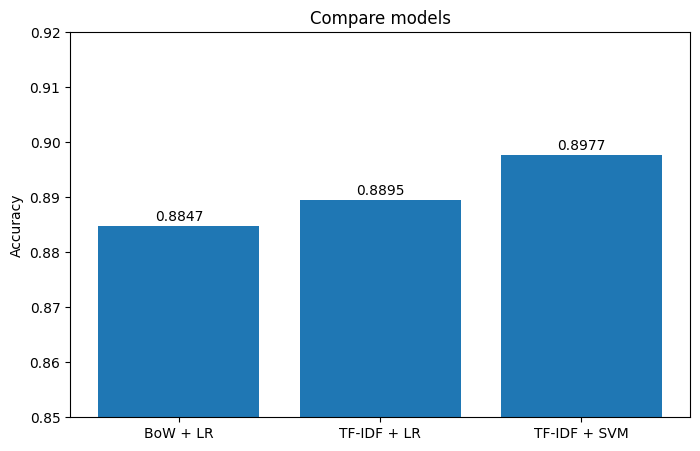

In [25]:
import matplotlib.pyplot as plt

models = ['BoW + LR', 'TF-IDF + LR', 'TF-IDF + SVM']
scores = [accuracy_score(Y_test, y_pred_bow), accuracy_score(Y_test, y_pred_tfidf), accuracy_score(Y_test, y_pred_svm)]

plt.figure(figsize=(8,5))
bars = plt.bar(models, scores)


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.001,
             f'{height:.4f}',
             ha='center')

plt.ylim(0.85, 0.92)
plt.ylabel("Accuracy")
plt.title("Compare models")
plt.show()

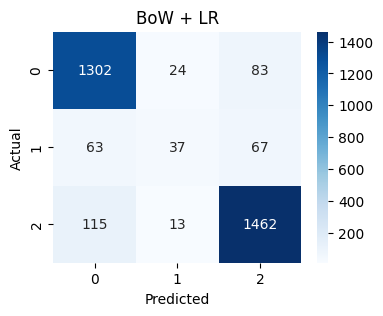

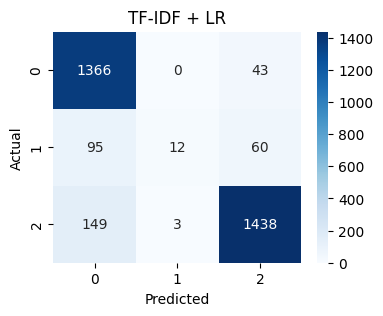

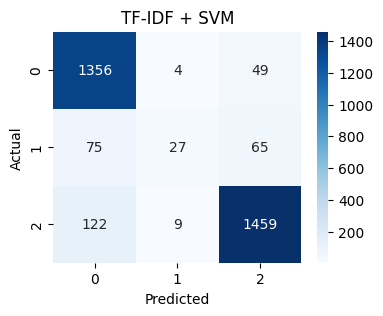

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(Y_test, y_pred_bow, "BoW + LR")
plot_cm(Y_test, y_pred_tfidf, "TF-IDF + LR")
plot_cm(Y_test, y_pred_svm, "TF-IDF + SVM")

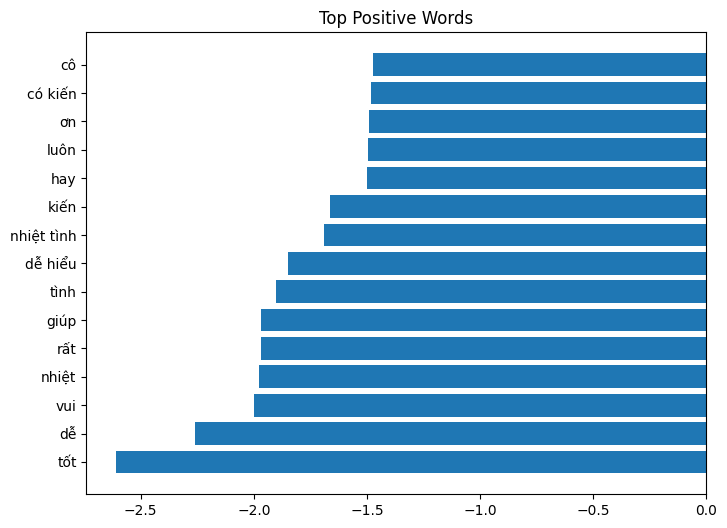

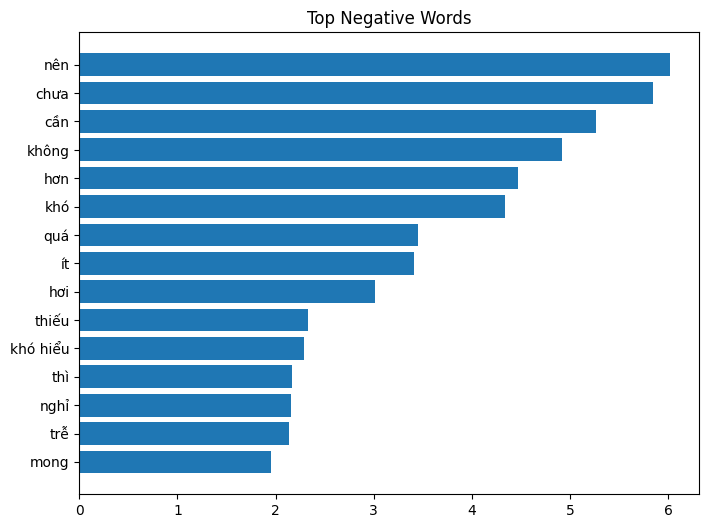

In [27]:
feature_names = tfidf_vectorizer.get_feature_names_out()
coef = model_tfidf.coef_[0]

top_negative_idx = coef.argsort()[-15:]
top_positive_idx = coef.argsort()[:15]

plt.figure(figsize=(8,6))
plt.barh(feature_names[top_positive_idx], coef[top_positive_idx])
plt.title("Top Positive Words")
plt.show()

plt.figure(figsize=(8,6))
plt.barh(feature_names[top_negative_idx], coef[top_negative_idx])
plt.title("Top Negative Words")
plt.show()

# II. Homework

## Exercise 1:

1. Try the following and **observe the accuracy changes**:

    - Change:
      ```python
      ngram_range=(1,3)

    *   Remove Vietnamese stopwords
    *   Experiment with:
      
        ```python
          max_features = 5000

``Homework 1:``

In [28]:
vi_stopwords = [
    "là", "của", "và", "các", "những", "một", "này", "cho", "với", "trong",
    "đã", "đang", "sẽ", "được", "bị", "tại", "như", "đó", "nếu", "thì",
    "mà", "nên", "tới", "vào", "nhiều", "ít", "nào", "chỉ", "cũng", "cứ",
    "vẫn", "thôi", "vậy", "rồi", "cái", "chiếc",
    "việc", "sự", "lúc", "khi"
]


In [29]:
tfidf_vctorizer = TfidfVectorizer(
    ngram_range = (1, 3),
    stop_words = vi_stopwords,
    max_features = 5000
)

Xtrain = tfidf_vctorizer.fit_transform(X_train)
Xtest = tfidf_vctorizer.transform(X_test)

In [30]:
def homework1():
  print("Exercise 1:")


  model = LogisticRegression(max_iter=1000)
  model.fit(Xtrain, Y_train)

  y_pred = model.predict(Xtest)
  acc = accuracy_score(Y_test, y_pred)
  print(f"Model: Logistic Regression + TF-IDF | Accuracy: {acc} comparing the given model accuracy LR + TF - IDF | Accuracy: {accuracy_score(Y_test, y_pred_tfidf)}")

  svm = LinearSVC()
  svm.fit(Xtrain, Y_train)

  svm_pred = svm.predict(Xtest)
  svm_acc = accuracy_score(Y_test, svm_pred)
  print(f"Model: SVM + TF-IDF | Accuracy: {svm_acc} comparing the given model accuracy SVM + TF - IDF | Accuracy: {accuracy_score(Y_test, y_pred_svm)}")


homework1()


Exercise 1:
Model: Logistic Regression + TF-IDF | Accuracy: 0.8752368919772584 comparing the given model accuracy LR + TF - IDF | Accuracy: 0.8894504106127605
Model: SVM + TF-IDF | Accuracy: 0.873973468098547 comparing the given model accuracy SVM + TF - IDF | Accuracy: 0.897662665824384


Limiting the model to only 5,000 features restricts its ability to capture a rich and diverse set of linguistic patterns, especially when using n-grams from 1 to 3. Additionally, removing stopwords may unintentionally eliminate important words related to negation and emphasis, such as “cũng” or “vẫn”, which are crucial for sentiment analysis. As a result, the model may lose important contextual information, leading to more frequent misclassifications.

Although stopword removal and feature limitation are commonly used techniques to reduce noise and dimensionality, our experiments show that they can negatively impact performance in this task. This is because TF-IDF already reduces the influence of frequent terms, and further removal of words may discard useful information. Therefore, a careful balance between feature selection and information preservation is necessary to achieve optimal performance.


## Excercise 2:

2. Try another model:
    *   Use Naive Bayes for sentiment classification.
    *   Error Analysis
        *   Print out 10 misclassified sentences
        *   Show the most important features (top weighted words)

``Homework 2``

In [31]:
def show_nb_features(vectorizer, nb_model, n=20):
    feature_names = vectorizer.get_feature_names_out()

    log_prob_neg = nb_model.feature_log_prob_[0]
    log_prob_pos = nb_model.feature_log_prob_[1]

    features_df = pd.DataFrame({
        'word': feature_names,
        'log_prob_neg': log_prob_neg,
        'log_prob_pos': log_prob_pos
    })

    features_df['diff'] = features_df['log_prob_pos'] - features_df['log_prob_neg']

    top_pos = features_df.sort_values(by='diff', ascending=False).head(n)

    top_neg = features_df.sort_values(by='diff', ascending=True).head(n)

    print(f"--- Top {n} POSITIVE characteristic words ---")
    print(top_pos[['word', 'diff']].to_string(index=False))

    print(f"\n--- Top {n} NEGATIVE characteristic words ---")
    print(top_neg[['word', 'diff']].to_string(index=False))

In [32]:
def homework2():
  print("Exercise 2:")
  nb_model = MultinomialNB()
  nb_model.fit(Xtrain, Y_train)

  y_pred = nb_model.predict(Xtest)
  acc_nb = accuracy_score(Y_test, y_pred)
  print(f"Model: Naive Bayes + TF-IDF | Accuracy: {acc_nb:.4f}")
  print("="*50)
  print("TOP 10 MISCLASSIFIED SENTENCES:")

  errors_found = 0
  test_sentences = list(X_test)
  actual_labels = list(Y_test)

  for i in range(len(y_pred)):
    if y_pred[i] != actual_labels[i]:
      print(f"Sentence: {test_sentences[i]}")
      print(f"   >>> Actual: {actual_labels[i]} | Predicted: {y_pred[i]}")
      print("-" * 30)
      errors_found += 1

    if errors_found == 10:
      break

  show_nb_features(tfidf_vctorizer, nb_model, n = 20)

homework2()

Exercise 2:
Model: Naive Bayes + TF-IDF | Accuracy: 0.8462
TOP 10 MISCLASSIFIED SENTENCES:
Sentence: nói tiếng anh lưu loát .
   >>> Actual: 2 | Predicted: 0
------------------------------
Sentence: tính điểm thi đua các nhóm .
   >>> Actual: 2 | Predicted: 0
------------------------------
Sentence: trong trường macbook thầy số hai thì không có máy nào số một .
   >>> Actual: 2 | Predicted: 0
------------------------------
Sentence: bắt đầu buổi học đúng giờ .
   >>> Actual: 2 | Predicted: 0
------------------------------
Sentence: cách mà cô tiếp cận với sinh viên .
   >>> Actual: 1 | Predicted: 2
------------------------------
Sentence: phòng học thoáng mát , trang thiết bị đầy đủ .
   >>> Actual: 2 | Predicted: 0
------------------------------
Sentence: môn học này giúp chúng em hiểu ra những vấn đề cơ bản .
   >>> Actual: 1 | Predicted: 0
------------------------------
Sentence: ổn .
   >>> Actual: 1 | Predicted: 0
------------------------------
Sentence: phần lớn chỉ là lý thuyết 

## Exercise 3:

3. Advance task

    *   Implement TF–IDF from scratch (USING FORMULAR)
    *   Compute TF, IDF
    *   Multiply them using the mathematical formula
    *   Using: TfidfVectorizer(analyzer='char', ngram_range=(3,5))
    *   Apply to another dataset
    *   Train and evaluate the model on a different dataset.
    *   Write a comparison report

``Homework 3``

### TfIDF from scratch

In [33]:
class TfIDF:
    def __init__(self, ngram_range=(1, 1), max_features=None):
        self.ngram_range = ngram_range
        self.max_features = max_features
        self.vocab = {}
        self.idf = None

    def _get_ngrams(self, text):
        words = text.split()
        all_ngrams = []
        min_n, max_n = self.ngram_range
        for n in range(min_n, max_n + 1):
            for i in range(len(words) - n + 1):
                gram = "_".join(words[i:i+n])
                all_ngrams.append(gram)
        return all_ngrams

    def _build_vocabulary(self, documents):
        df_counts = Counter()
        for doc in documents:
            grams = set(self._get_ngrams(doc))
            for g in grams:
                df_counts[g] += 1

        sorted_vocab = sorted(df_counts.items(), key=lambda x: x[1], reverse=True)
        if self.max_features:
            sorted_vocab = sorted_vocab[:self.max_features]

        self.vocab = {word: i for i, (word, _) in enumerate(sorted_vocab)}
        return df_counts

    def _compute_idf(self, total_docs, df_counts):
        self.idf = np.zeros(len(self.vocab))
        for word, idx in self.vocab.items():
            df = df_counts[word]
            self.idf[idx] = math.log((total_docs + 1) / (df + 1)) + 1

    def _compute_tf(self, ngrams_list):
        tf_dict = {}
        doc_len = len(ngrams_list)
        if doc_len == 0:
            return tf_dict

        gram_counts = Counter(ngrams_list)
        for word, count in gram_counts.items():
            if word in self.vocab:
                word_idx = self.vocab[word]
                tf_dict[word_idx] = count / doc_len
        return tf_dict

    def fit(self, documents):
        total_docs = len(documents)
        df_counts = self._build_vocabulary(documents)
        self._compute_idf(total_docs, df_counts)
        return self

    def transform(self, documents):
        rows, cols, values = [], [], []

        for row_idx, doc in enumerate(documents):
            ngrams_list = self._get_ngrams(doc)
            tf_dict = self._compute_tf(ngrams_list)

            for col_idx, tf_val in tf_dict.items():
                tfidf_val = tf_val * self.idf[col_idx]
                rows.append(row_idx)
                cols.append(col_idx)
                values.append(tfidf_val)

        return csr_matrix((values, (rows, cols)), shape=(len(documents), len(self.vocab)))

### Applying IMDb dataset

#### 1. Getting the IMDb dataset

In [34]:
!pwd
!wget https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

/content
--2026-04-09 14:19:35--  https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘aclImdb_v1.tar.gz.1’

aclImdb_v1.tar.gz.1 100%[===================>]  80.23M  36.9MB/s    in 2.2s    

2026-04-09 14:19:37 (36.9 MB/s) - ‘aclImdb_v1.tar.gz.1’ saved [84125825/84125825]



In [35]:
!tar -xvf aclImdb_v1.tar.gz

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
aclImdb/train/unsup/44983_0.txt
aclImdb/train/unsup/44982_0.txt
aclImdb/train/unsup/44981_0.txt
aclImdb/train/unsup/44980_0.txt
aclImdb/train/unsup/44979_0.txt
aclImdb/train/unsup/44978_0.txt
aclImdb/train/unsup/44977_0.txt
aclImdb/train/unsup/44976_0.txt
aclImdb/train/unsup/44975_0.txt
aclImdb/train/unsup/44974_0.txt
aclImdb/train/unsup/44973_0.txt
aclImdb/train/unsup/44972_0.txt
aclImdb/train/unsup/44971_0.txt
aclImdb/train/unsup/44970_0.txt
aclImdb/train/unsup/44969_0.txt
aclImdb/train/unsup/44968_0.txt
aclImdb/train/unsup/44967_0.txt
aclImdb/train/unsup/44966_0.txt
aclImdb/train/unsup/44965_0.txt
aclImdb/train/unsup/44964_0.txt
aclImdb/train/unsup/44963_0.txt
aclImdb/train/unsup/44962_0.txt
aclImdb/train/unsup/44961_0.txt
aclImdb/train/unsup/44960_0.txt
aclImdb/train/unsup/44959_0.txt
aclImdb/train/unsup/44958_0.txt
aclImdb/train/unsup/44957_0.txt
aclImdb/train/unsup/44956_0.txt
aclImdb/train/unsup/44955_0.txt
aclImdb/train/u

In [36]:
!ls aclImdb/train/pos/

0_9.txt       11876_10.txt  2501_8.txt	 4377_10.txt  625_10.txt   8127_8.txt
10000_8.txt   11877_10.txt  2502_8.txt	 4378_9.txt   6251_7.txt   8128_10.txt
10001_10.txt  11878_10.txt  2503_10.txt  4379_8.txt   6252_10.txt  8129_9.txt
10002_7.txt   11879_10.txt  2504_10.txt  437_9.txt    6253_8.txt   8130_10.txt
10003_8.txt   11880_10.txt  2505_9.txt	 4380_8.txt   6254_10.txt  813_10.txt
10004_8.txt   11881_9.txt   2506_9.txt	 4381_10.txt  6255_8.txt   8131_8.txt
10005_7.txt   11882_8.txt   2507_7.txt	 4382_8.txt   6256_8.txt   8132_10.txt
10006_7.txt   11883_8.txt   250_7.txt	 4383_9.txt   6257_10.txt  8133_7.txt
10007_7.txt   11884_8.txt   2508_10.txt  4384_10.txt  6258_8.txt   8134_10.txt
10008_7.txt   11885_7.txt   2509_9.txt	 4385_9.txt   6259_8.txt   8135_10.txt
1000_8.txt    11886_10.txt  2510_10.txt  4386_9.txt   6260_10.txt  8136_9.txt
10009_9.txt   11887_8.txt   251_10.txt	 4387_9.txt   6261_8.txt   8137_10.txt
10010_7.txt   11888_9.txt   2511_10.txt  4388_9.txt   6262_9.txt   

#### 2. Preprocessing data

In [37]:
def split_subtext(text):
  return re.split(r"(?:@ )+| ?</?p> ?| ?<br /> ?", text.rstrip())

def clean_text(text):
    return re.sub(r'#[^ ]+ ?|@[^ ]+ ?', '', text)

def preprocess(text):
    text = text.replace("b'", "")
    sent = split_subtext(text)

    sents = []
    for s in sent:
      sents.append(" ".join(word_tokenize(clean_text(s))))
    return " ".join(sents)

#### 3. Loading dataset

In [38]:
train_data = load_files(
    "./aclImdb/train",
    categories=['pos', 'neg'],
    shuffle=True
)

test_data = load_files(
    "./aclImdb/test",
    categories=['pos', 'neg'],
    shuffle=True
)

X_train = [x.decode("utf-8") for x in train_data.data]
y_train = train_data.target

X_test  = [x.decode("utf-8") for x in test_data.data]
y_test  = test_data.target

#### Train model using sklearn Tfidf

In [39]:
vectorizer = TfidfVectorizer(
    analyzer='char',
    stop_words="english",
    ngram_range=(3, 5),
    max_features=5000,
)

In [40]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:539: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


In [41]:
model = LogisticRegression(
    max_iter=1000,
    solver='liblinear'
)

model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [42]:
y_pred = model.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy of Logistic Regression using sklearn tfidfVectorizer:", acc)

Accuracy of Logistic Regression using sklearn tfidfVectorizer: 0.85392


#### Train model using TfIdf from scratch

In [43]:
tfidf = TfIDF(
    ngram_range = (3, 5),
    max_features = 5000
)

In [44]:
train_inputs = tfidf.fit(X_train).transform(X_train)
test_inputs = tfidf.transform(X_test)

In [45]:
lr_model = LogisticRegression(
    max_iter=1000,
    solver='liblinear'
)

In [46]:
lr_model.fit(train_inputs, y_train)
y_pred = lr_model.predict(test_inputs)
acc = accuracy_score(y_test, y_pred)
print(f"Model: Logistic Regression + TF-IDF from scratch| Accuracy: {acc:.4f}")

Model: Logistic Regression + TF-IDF from scratch| Accuracy: 0.7440


Overall, implementing the model using both sklearn's tfidf and tfidf from scratch yields good outcomes. However, the accuracy of the former method (85%) is superior to that of the latter (75%) by roughly 11%.

## Excercise 4:

4. Rebuild the Naive Bayes Model Using Advanced Techniques
    * Combine N-gram Features with TF–IDF: Use both **unigram + bigram** to capture more context
    * Cross-validation: Instead of using a single train/test split, use k-fold cross-validation
    * Hyperparameter Tuning with GridSearchCV: search for the best parameter combination automatically.

In [47]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

In [48]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [49]:
nb_model = MultinomialNB()

In [50]:
param_grid = {
        'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]
    }

In [51]:
grid_search = GridSearchCV(
        estimator=nb_model,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )

In [52]:
grid_search.fit(X_train_vec, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]},
             scoring='accuracy', verbose=1)

In [53]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_vec)

In [54]:
final_acc = accuracy_score(y_test, y_pred)

In [55]:
print(f"Final Accuracy on Test Data: {final_acc:.4f}")

Final Accuracy on Test Data: 0.8558
